### Quasi Random Sampling for Linear Region Counting

In this notebook, we count linear regions using quasi-random sampling as an alternative to iid uniform sampling. We will investigate how the variance and convergence rate of our estimate of the number of linear regions is different from using iid uniform sampling on the input space.

We will use the following quasi-random sampling methods:
- Halton Sequences
- Poisson Disk Sampling??

#### Imports:

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from sklearn.svm import SVC

In [12]:
from scipy.stats import qmc

#### Code to generate Randomised Halton Sequence:

In [26]:
def halton_sequence(num_points,dimensions, lower_bound, upper_bound, seed):
    """Generates a randomised Halton Sequence in some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        lower_bound: lower bound of each dimension of the sampling region
        upper_bound: upper bound of each dimension of the sampling region
        seed: the random seed used for scrambling (for reproducibility)
    Returns:
        points: 2D array of shape (num_points,dimensions) representing all the points
    """

    # Generate Halton sequence in [0,1]^d
    halton_sampler = qmc.Halton(d=dimensions,scramble=True,seed=seed)
    points = halton_sampler.random(n=num_points)
    # Map to the desired region
    points = points*(upper_bound-lower_bound) + lower_bound
    return points

Test function and display resulting sample:

In [29]:
num_points = 1000
dimensions = 5
lower_bound = -1
upper_bound = 1
points = halton_sequence(num_points,dimensions,lower_bound,upper_bound,seed=56)

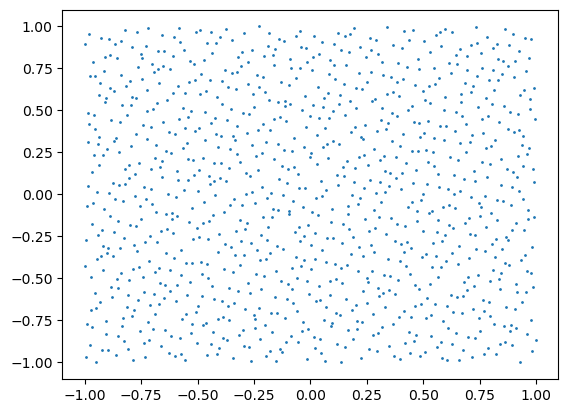

In [31]:
plt.scatter(points[:,0],points[:,1],s=1)

#### Code to set up MLP

Define class for a flexible MLP. It should allow the user to specify:
1. Dimension of the input space
2. Number of hidden neurons in each layer of the network (and therefore number of hidden layers)
3. Whether to use custom (user-provided) initial weights or to set them using Kaiming Normal Distribution (He initialisation)

In [32]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 2D array of inputs of shape (batch size, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 2D array of shape: (batch size, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after linear layers
            if isinstance(layer,torch.nn.Linear):
                try:
                    activations = np.concatenate((activations,x.detach().numpy()),axis=1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x.detach().numpy()
        return activations

#### Code to count activation patterns/linear regions:

Create custom PyTorch dataset to process a batch of input points:

In [33]:
class SampleDataset(torch.utils.data.Dataset):
    """Custom dataset designed to store samples to be used in linear region counting"""

    def __init__(self, points):
        # self.points = array of samples of shape (num_points,input dimension)
        self.points = points
        
    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self,index):
        inputs = self.points[index,:]
        return inputs

Function to get numbers of unique linear regions after $N$ samples, $U(N)$:

In [34]:
def region_count(sample_data_loader,model):
    """Count the number of unique linear regions in the input space of a MLP using
    random sample of points from that input space

    Args:
        sample_data_loader: the data loader used to process the input data in batches
        model: the neural network model we are analysing
    Returns:
        unique_counts: a list of the number of regions found after each new sample
        samples_by_region: a dictionary containing each activation pattern and an array of input samples with that pattern
    """

    # Set list for the count after each sample
    # Set dictionary for the activation patterns and the samples corresponding to them
    unique_counts = []
    samples_by_region = {}

    for inputs in sample_data_loader:

        inputs = inputs.float()
        activations = model(inputs)

        # For each example in the batch
        for i in range(activations.shape[0]):

            # Get input point
            input_point = inputs[i,:].detach().numpy()

            # Get the activation pattern from the activation values
            example_values = activations[i,:]
            activation_pattern = ""
            for value in example_values:
                if value > 0:
                    activation_pattern += "1"
                else:
                    activation_pattern += "0"

            # If the activation pattern has already been seen, look up the pattern, add the samples
            # and keep the count the same
            try:
                sample_points = samples_by_region[activation_pattern]
                sample_points = np.vstack((sample_points,input_point))
                samples_by_region[activation_pattern] = sample_points
                unique_counts.append(unique_counts[-1])

            # If we haven't seen the pattern before, then trying to access it in the dictionary will
            # raise a KeyError - in this case add the pattern to the dictionary and increase count by 1
            except KeyError:

                if len(unique_counts)==0:
                    unique_counts.append(1)
                else:
                    unique_counts.append(unique_counts[-1]+1)

                samples_by_region[activation_pattern] = np.array([input_point])
                            
    return unique_counts, samples_by_region

#### Test: run code on simple example neural networks and verify output

Example 1: Put all the functions together to estimate linear region count in a simple neural network with a 2D input, single hidden layer, 2 hidden neurons and specific weights:

In [39]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-3)
upper_bounds = np.full(dimensions,3)
rng = np.random.default_rng(seed=1)

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sequence(num_points,dimensions,lower_bounds,upper_bounds,rng)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
unique_counts, samples_by_region = region_count(sample_data_loader,model)

Plot the number of linear regions found in terms of the number of samples:

Text(0, 0.5, 'U(N)')

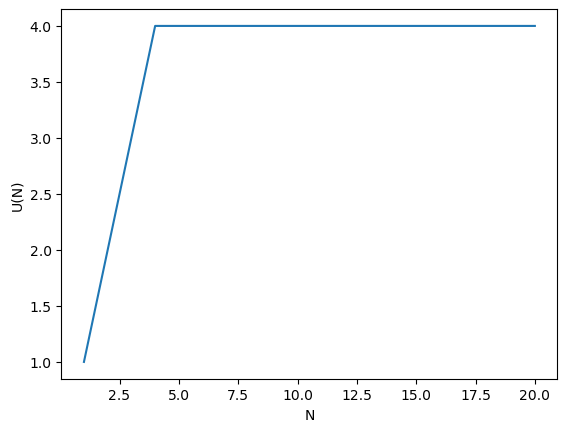

In [40]:
y = unique_counts[0:20]
x = np.arange(1,len(y)+1)
plt.plot(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

Text(0, 0.5, '$x_{2}$')

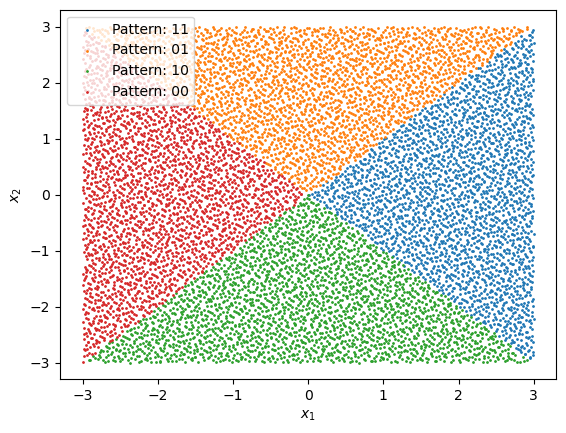

In [41]:
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.legend()
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

In this example:
- There are exactly 4 unique linear regions found, which is exactly what we expect from the theory
- The linear regions occupy 4 quadrants of the grid, and the patterns of each quadrant are exactly what we expect from the theory

This demonstrates that the MLP class and region counting function work correctly.

Example 2: The example in Figure 2 from Bounding and Counting Linear Regions of Deep Neural Networks

In [42]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2,2,2]
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]),torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bound = -0.5
upper_bound = 4.5

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sequence(num_points,dimensions,lower_bound,upper_bound,seed=10)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
unique_counts, samples_by_region = region_count(sample_data_loader,model)

Text(0, 0.5, 'U(N)')

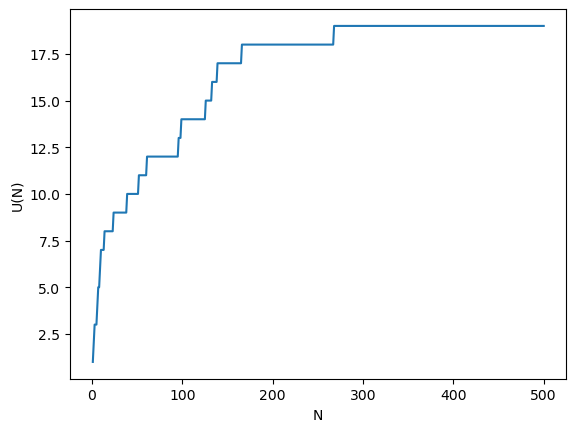

In [43]:
y = unique_counts[:500]
x = np.arange(1,len(y)+1)
plt.plot(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

Text(0, 0.5, '$x_{2}$')

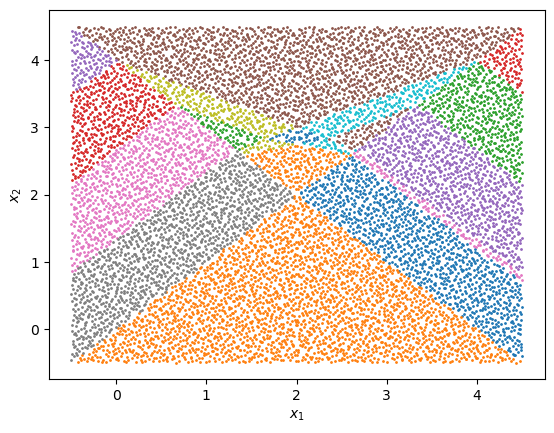

In [44]:
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

The number of regions and the shape of the regions is exactly the same as shown in the paper (which was done using exact calculations). This provides further evidence that the code works.

Below is a function for an experiment to determine how the variance of the linear regions depends on number of hidden layers and dimension of the input space:

EXPERIMENT 1:
- 100000 samples
- 50 independent runs
- [5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

#### Variance and Dimension Experiments (WITH BIAS)

This demonstrates that smaller linear regions tend to occur in groups, so there are some areas where the regions are very dense and other areas where the regions are sparse -> we could guide the sampler to look in areas where we have found more linear regions by sampling in batches

In [45]:
def experiment_1(num_points, num_runs, neurons_per_hidden, dimensions):
    """Determine how variance of linear region count depends on number of hidden layers and dimension of input space.
    
    Args:
        num_points: the number of input points to randomly sample
        num_runs: the number of runs to calculate variance across
        neurons_per_hidden: the number of hidden neurons in each layer
        dimensions: the dimension of the input space
    Returns:
        total_unique_counts: the number of linear regions found after each sample
        variances: the run-to-run variance after each number of samples
        total_samples_by_region: the samples for each linear region for all 50 runs
    """

    total_samples_by_region = []
    total_variances = []
    unique_counts_dimension = []
    
    for i in range(len(dimensions)):
    
        # Initialise the model
        lower_bound = -1.0
        upper_bound = 1.0
        model = MLP(dimensions[i],neurons_per_hidden)
    
        total_unique_counts = np.empty((num_runs,num_points))
        
        for j in range(num_runs):
            points = halton_sequence(num_points,dimensions[i],lower_bound,upper_bound,seed=j)
            sample_dataset = SampleDataset(points)
            sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=256, shuffle=False)
            unique_counts, samples_by_region = region_count(sample_data_loader,model)
            total_unique_counts[j,:] = unique_counts
    
        variances = np.var(total_unique_counts,axis=0)
        total_samples_by_region.append(samples_by_region)
        total_variances.append(variances)
        unique_counts_dimension.append(total_unique_counts)
    
    return unique_counts_dimension, total_variances, total_samples_by_region

Quick test run:

In [46]:
num_points = 1000000
num_runs = 50
neurons_per_hidden = [5,5]
dimensions = [7]

start_time = time.time()
unique_counts_dimension_1, total_variances_1, total_samples_by_region_1 = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_1 = end_time - start_time

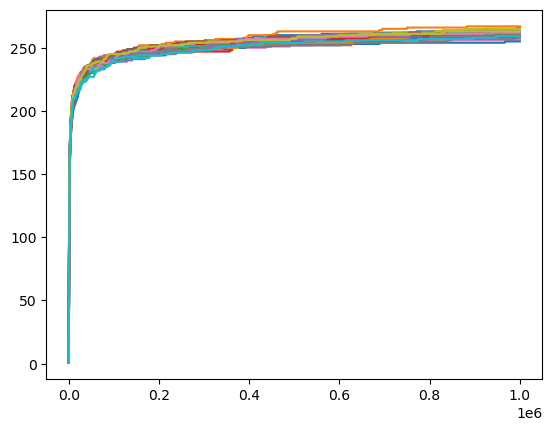

In [65]:
x = np.arange(1000000)
discovery_curves = unique_counts_dimension_1[0]
for i in range(50):
    plt.plot(x,discovery_curves[i,:])

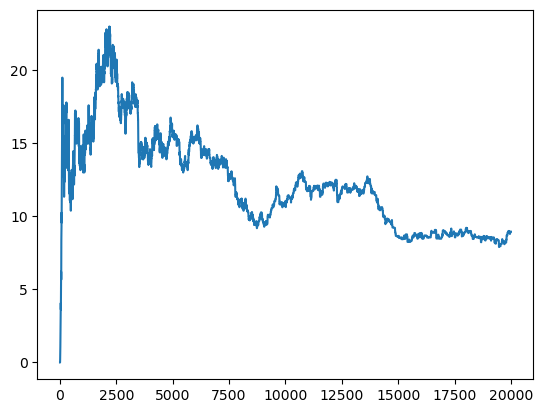

In [59]:
plt.plot(x[:20000],total_variances_1[0][:20000])

In [57]:
max_variances = [max(variance_array) for variance_array in total_variances_1]

In [58]:
print(max_variances)

[22.987600000000015]


From this test run, using the Halton sequence has managed to reduce the variance quite a bit (comparing to the maximum variance in the case of the iid uniform sampling).

EXPERIMENT 1:
- 1 million samples
- 50 independent runs
- [5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [46]:
num_points = 1000000
num_runs = 50
neurons_per_hidden = [5,5]
dimensions = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

start_time = time.time()
unique_counts_dimension_1, total_variances_1, total_samples_by_region_1 = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_1 = end_time - start_time

Text(0, 0.5, 'Maximum Variance')

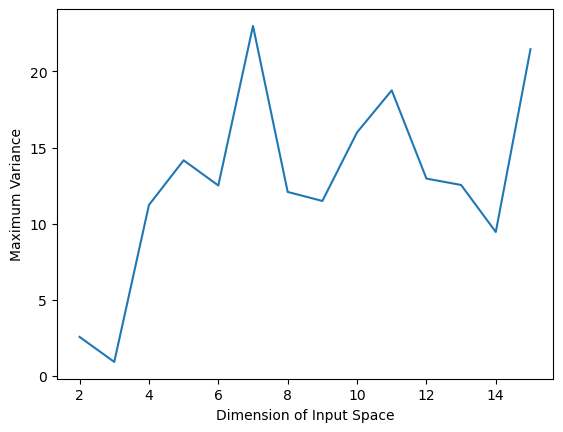

In [77]:
max_variances = [max(variance_array) for variance_array in total_variances_1]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Compare to iid uniform:

Text(0, 0.5, 'Maximum Variance')

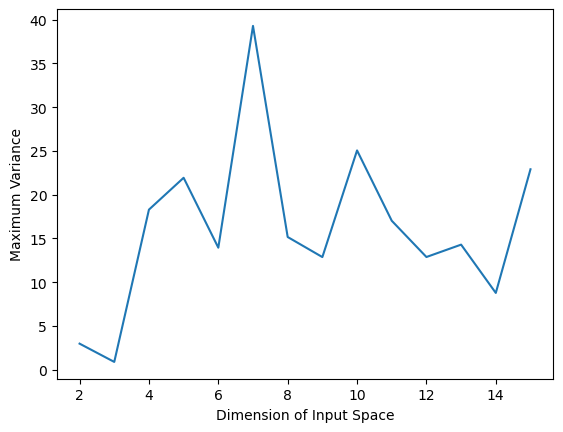

In [625]:
max_variances = [max(variance_array) for variance_array in total_variances_1]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

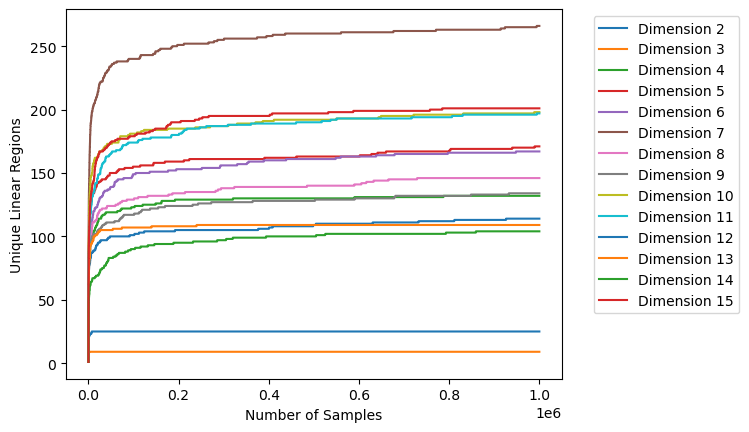

In [78]:
x = np.arange(1000000)
i=0
for discovery_curves in unique_counts_dimension_1:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Compare to iid uniform:

Text(0, 0.5, 'Unique Linear Regions')

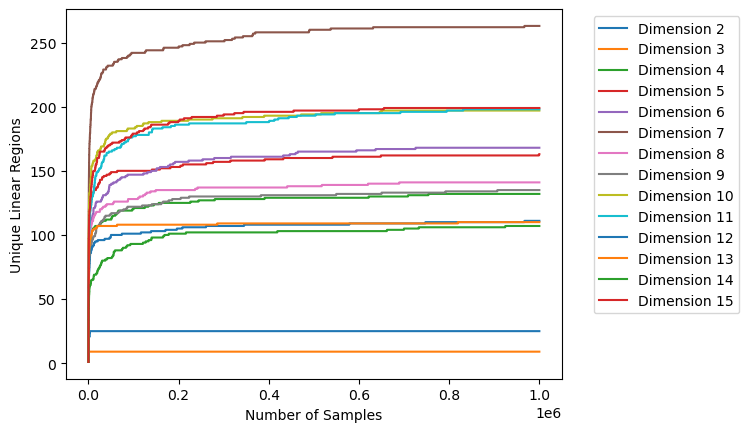

In [633]:
x = np.arange(1000000)
i=0
for discovery_curves in unique_counts_dimension_1:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

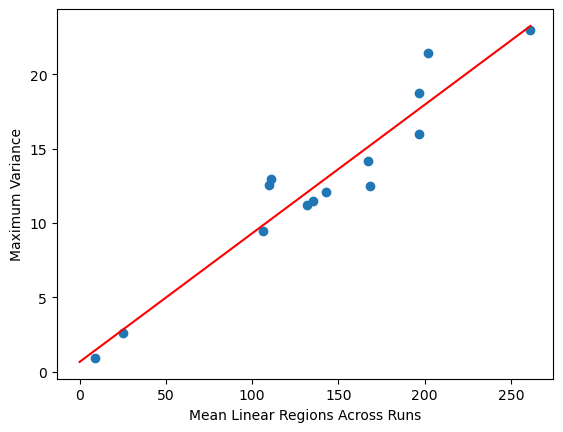

In [79]:
total_regions = [np.mean(unique_counts_dimension_1[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

Compare to iid uniform:

Text(0, 0.5, 'Maximum Variance')

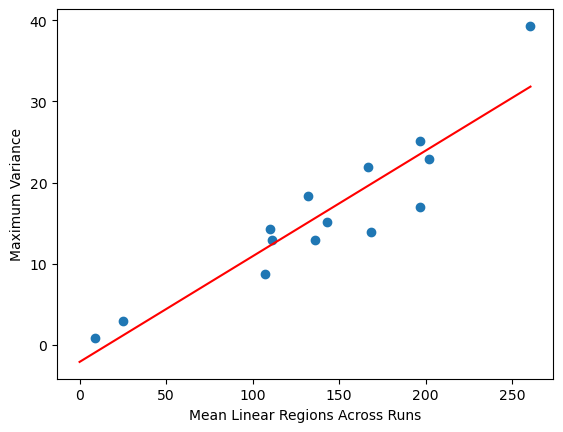

In [629]:
total_regions = [np.mean(unique_counts_dimension_1[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 2:
- 1 million samples
- 50 independent runs
- [5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [48]:
num_points = 1000000
num_runs = 50
neurons_per_hidden = [5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

start_time = time.time()
unique_counts_dimension_2, total_variances_2, total_samples_by_region_2 = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_2 = end_time - start_time

Text(0, 0.5, 'Maximum Variance')

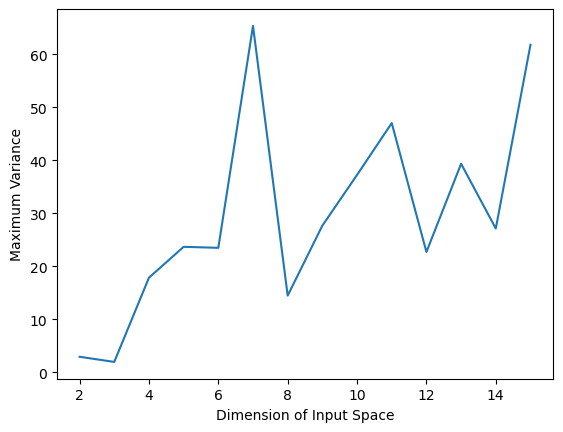

In [85]:
max_variances = [max(variance_array) for variance_array in total_variances_2]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Compare to iid uniform sampling:

Text(0, 0.5, 'Maximum Variance')

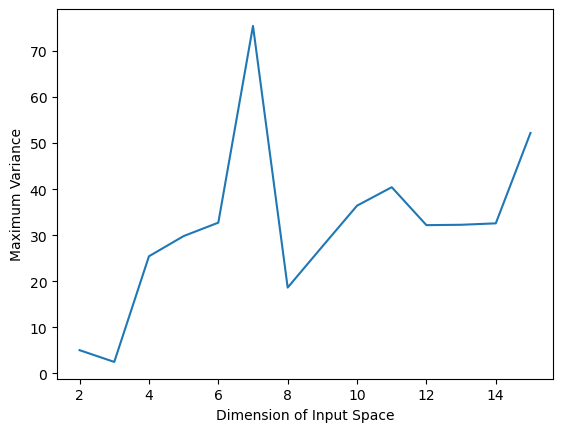

In [637]:
max_variances = [max(variance_array) for variance_array in total_variances_2]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

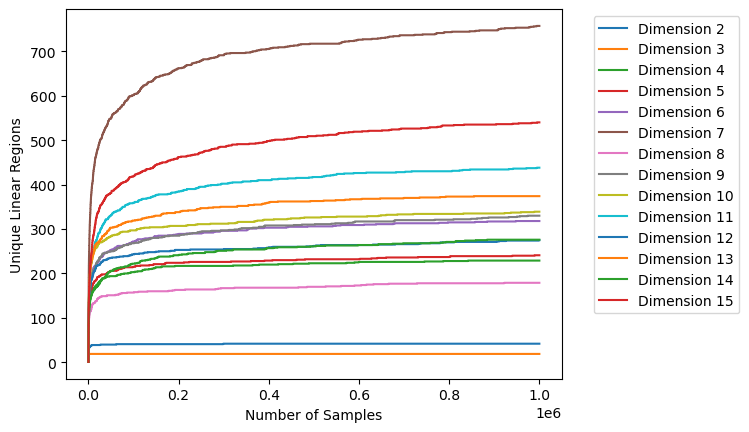

In [86]:
x = np.arange(1000000)
i=0
for discovery_curves in unique_counts_dimension_2:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Compare to iid uniform sampling:

Text(0, 0.5, 'Unique Linear Regions')

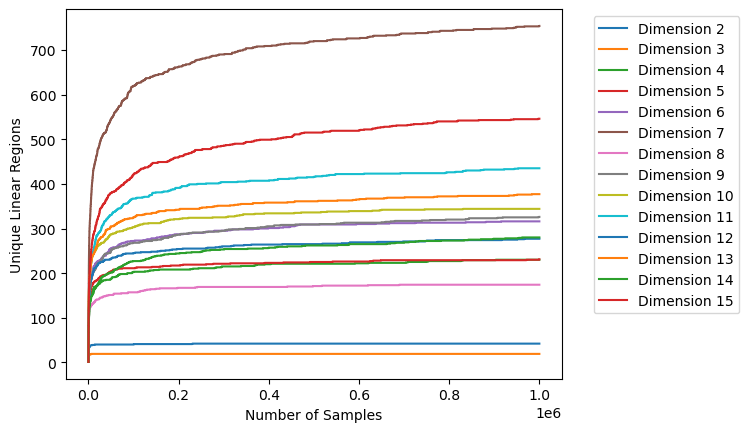

In [638]:
x = np.arange(1000000)
i=0
for discovery_curves in unique_counts_dimension_2:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

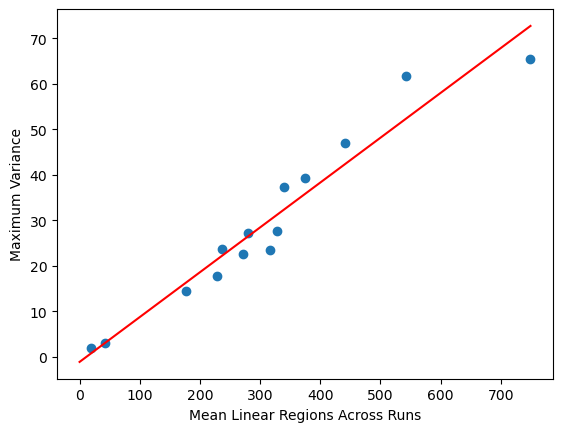

In [87]:
total_regions = [np.mean(unique_counts_dimension_2[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 3:
- 2 million samples
- 50 independent runs
- [5,5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [88]:
num_points = 2000000
num_runs = 50
neurons_per_hidden = [5,5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

start_time = time.time()
unique_counts_dimension_3, total_variances_3, total_samples_by_region_3 = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_3 = end_time - start_time

Text(0, 0.5, 'Maximum Variance')

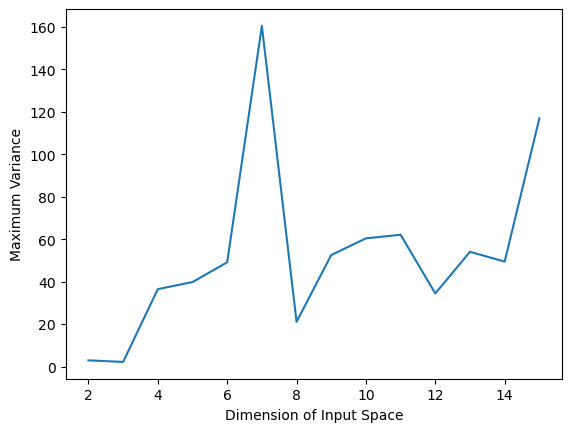

In [89]:
max_variances = [max(variance_array) for variance_array in total_variances_3]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Compare to iid uniform sampling:

Text(0, 0.5, 'Maximum Variance')

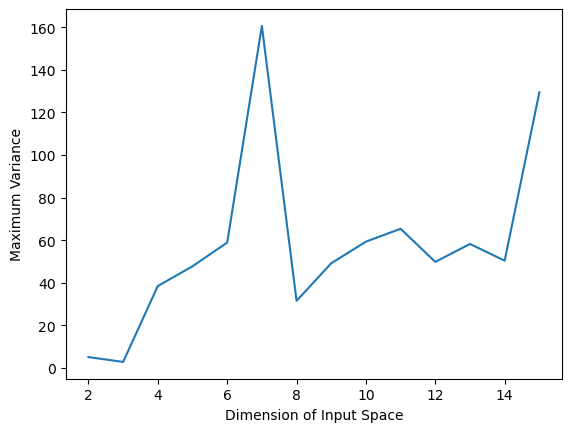

In [641]:
max_variances = [max(variance_array) for variance_array in total_variances_3]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

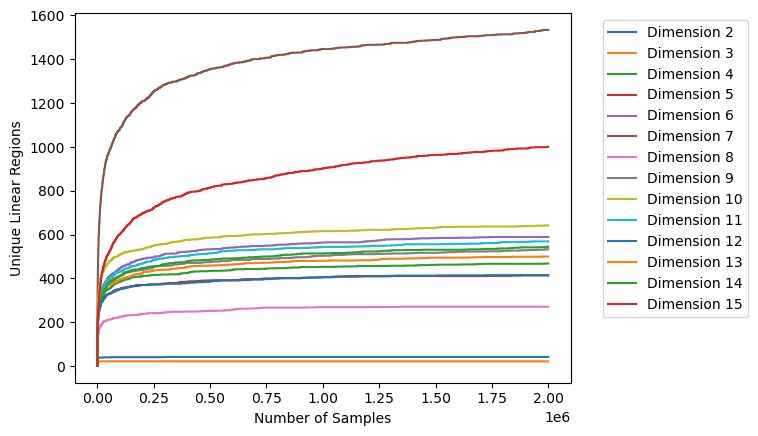

In [90]:
x = np.arange(2000000)
i=0
for discovery_curves in unique_counts_dimension_3:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Compare to iid uniform sampling:

Text(0, 0.5, 'Unique Linear Regions')

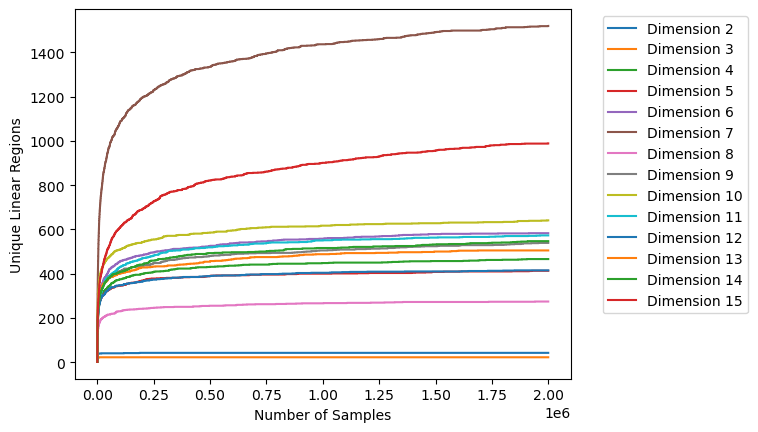

In [642]:
x = np.arange(2000000)
i=0
for discovery_curves in unique_counts_dimension_3:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

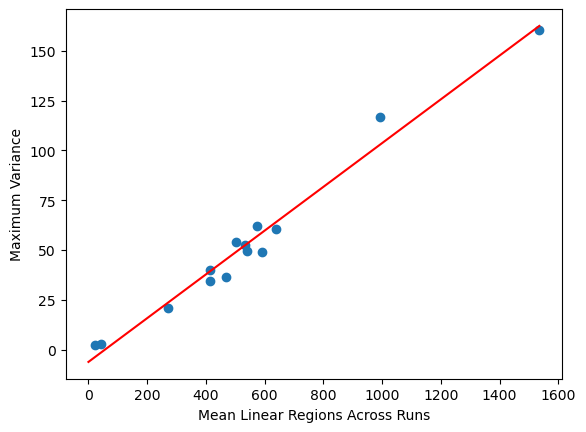

In [91]:
total_regions = [np.mean(unique_counts_dimension_3[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

In [95]:
print(max_variances[13])

116.9236


Text(0, 0.5, 'Maximum Variance')

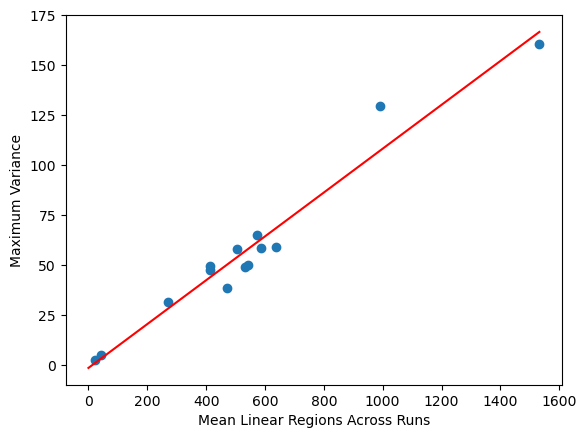

In [643]:
total_regions = [np.mean(unique_counts_dimension_3[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

EXPERIMENT 4:
- 10 million samples
- 50 independent runs
- [5,5,5,5,5] neurons per hidden layer
- [2,3,4,5,6,7,8,9,10] dimensions

In [644]:
num_points = 2000000
num_runs = 50
neurons_per_hidden = [5,5,5,5,5]
dimensions = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

start_time = time.time()
unique_counts_dimension_4, total_variances_4, total_samples_by_region_4 = experiment_1(num_points,num_runs,neurons_per_hidden,dimensions)
end_time = time.time()
time_4 = end_time - start_time

Text(0, 0.5, 'Maximum Variance')

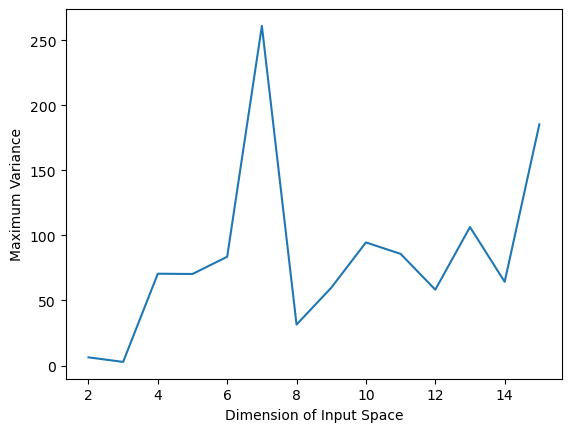

In [645]:
max_variances = [max(variance_array) for variance_array in total_variances_4]
plt.plot(dimensions,max_variances)
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Unique Linear Regions')

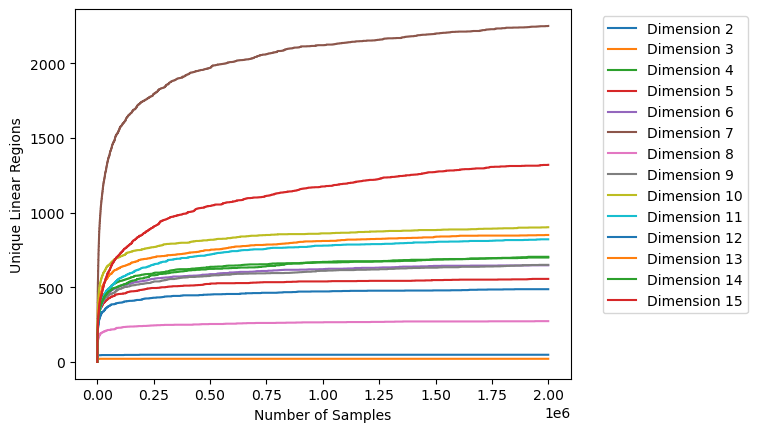

In [646]:
x = np.arange(2000000)
i=0
for discovery_curves in unique_counts_dimension_4:
    plt.plot(x,discovery_curves[0,:],label=f"Dimension {dimensions[i]}")
    i+=1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")

Text(0, 0.5, 'Maximum Variance')

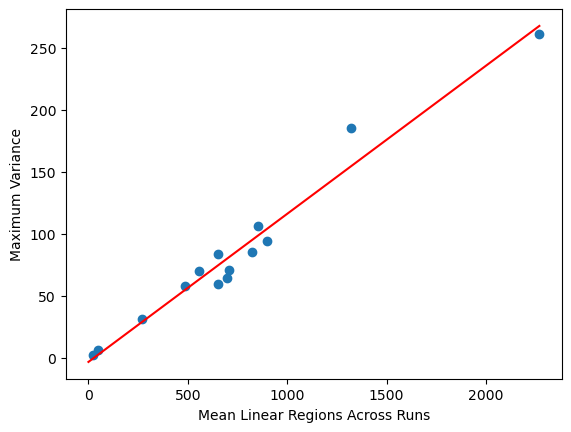

In [647]:
total_regions = [np.mean(unique_counts_dimension_4[i][:,-1]) for i in range(len(dimensions))]
plt.scatter(total_regions,max_variances)
coefs = np.polyfit(total_regions,max_variances,deg=1)
x = np.linspace(0,max(total_regions),1000)
y = coefs[1] + coefs[0]*x
plt.plot(x,y,color="red")
plt.xlabel("Mean Linear Regions Across Runs")
plt.ylabel("Maximum Variance")

SAVE ALL DATA TO .npy FILES:

In [ ]:
np.save("/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/counts_h_1.npy",unique_counts_dimension_1)

np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/variances_h_1.npy',total_variances_1)

np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/samples_by_region_1.npy',total_samples_by_region_1)

In [55]:
np.save("/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/counts_h_2.npy",unique_counts_dimension_2)

np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/variances_h_2.npy',total_variances_2)

np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_halton/samples_by_region_2.npy',total_samples_by_region_2)

#### Compare quasi-random results to iid uniform results

Load results from iid uniform sampling:

In [200]:
data = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_with_bias/counts_1.npy', mmap_mode='r')

In [201]:
variances = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_with_bias/variances_1.npy',mmap_mode="r")

Plot variances in terms of number of samples for 3 different dimensions:

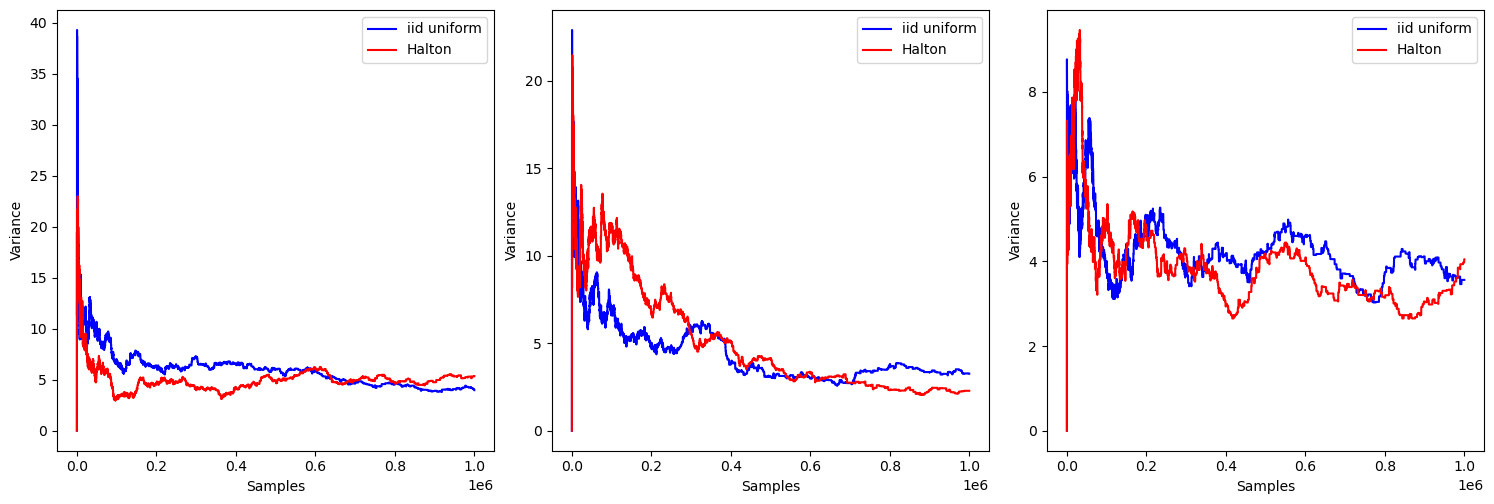

In [224]:
x = np.arange(1000000)
fig, axs = plt.subplots(1,3,figsize=(15,5))
fig.tight_layout()
axs[0].plot(x,variances[5,:],color="blue",label="iid uniform")
axs[0].plot(x,total_variances_1[5],color="red",label="Halton")
axs[0].set_xlabel("Samples")
axs[0].set_ylabel("Variance")
axs[0].legend()

axs[1].plot(x,variances[13,:],color="blue",label="iid uniform")
axs[1].plot(x,total_variances_1[13],color="red",label="Halton")
axs[1].set_xlabel("Samples")
axs[1].set_ylabel("Variance")
axs[1].legend()

axs[2].plot(x,variances[12,:],color="blue",label="iid uniform")
axs[2].plot(x,total_variances_1[12],color="red",label="Halton")
axs[2].set_xlabel("Samples")
axs[2].set_ylabel("Variance")
axs[2].legend()

This demonstrates that counting linear regions using a Halton Sequence is quite hit-and-miss: sometimes, there is a significant reduction in variance, as shown in the first graph (dimension 5). But the variance is never consistently below the iid uniform sampling for any number of samples, often it alternates between being above and below the iid uniform sampling.

Plot maximum variance as a function of dimension:

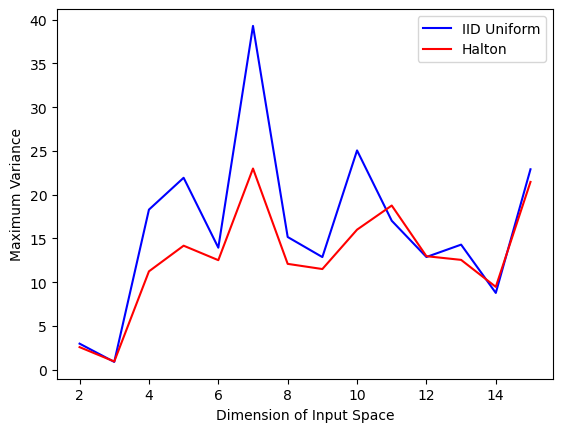

In [227]:
max_variances_halton = [max(variance_array) for variance_array in total_variances_1]
max_variances_iid = [max(variance_array) for variance_array in variances]
plt.plot(dimensions,max_variances_iid,color="blue",label="IID Uniform")
plt.plot(dimensions,max_variances_halton,color="red",label="Halton")
plt.xlabel("Dimension of Input Space")
plt.ylabel("Maximum Variance")
plt.legend()

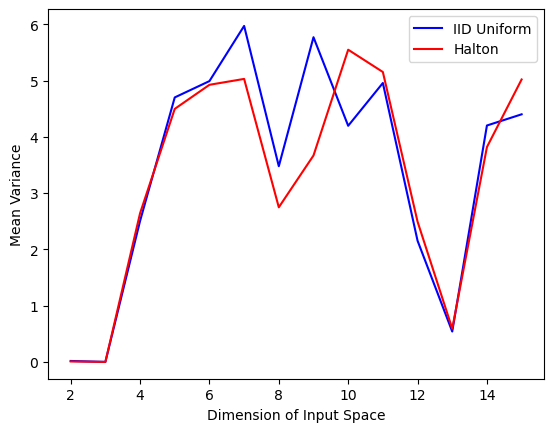

In [229]:
mean_variances_halton = [np.mean(variance_array,axis=0) for variance_array in total_variances_1]
mean_variances_iid = [np.mean(variance_array,axis=0) for variance_array in variances]
plt.plot(dimensions,mean_variances_iid,color="blue",label="IID Uniform")
plt.plot(dimensions,mean_variances_halton,color="red",label="Halton")
plt.xlabel("Dimension of Input Space")
plt.ylabel("Mean Variance")
plt.legend()

For this network, the maximum variance is mostly lower or very similar when using the Halton Sequence than iid uniform sampling, but the mean variance is sometimes lower and sometimes higher. This is probably because the variance does not get as high for small sample sizes but may take longer to come down for small sample sizes.

Repeating this analysis for the larger network sizes does not show a substantial difference in maximum variance between iid uniform sampling and using a Halton Sequence:

Question: why has using a Halton sequence reduced the maximum variance in some cases but not in others?

- In a Halton Sequence, the points are supposed to be more evenly distributed in space than iid uniform sampling, so perhaps variance is reduced in cases where the linear regions have more similar sizes and are more evenly arranged in space, and has less of an effect in cases where the regions have different sizes and shapes and are clumped together.
  
- Perhaps should look into using the samples to estimate the volume of regions, then compare relative sizes in the cases where variance has been reduced and not?

#### Graph for poster

In [3]:
data = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_1_with_bias/counts_2.npy', mmap_mode='r')

Text(0, 0.5, 'Unique Linear Regions')

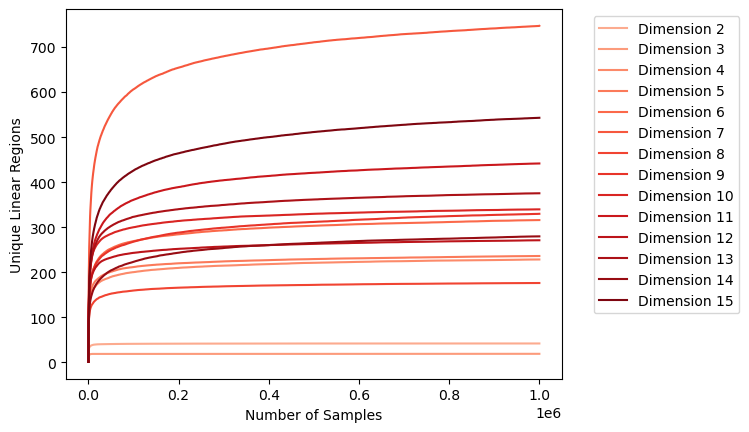

In [9]:
cmap = plt.get_cmap('Reds')
colors = cmap(np.linspace(0.3, 1.0, 15))
dimensions = [2,3,4,5,6,7,8,9,10,11,12,13,14,15]

x = np.arange(1000000)
i=0
for discovery_curves in data:
    plt.plot(x,np.mean(discovery_curves,axis=0),label=f"Dimension {dimensions[i]}",color=colors[i])
    i+=1
plt.legend(bbox_to_anchor=(1.05,1.0),loc='upper left')
plt.xlabel("Number of Samples")
plt.ylabel("Unique Linear Regions")